In [116]:
import torch 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sb
from torch import nn 

In [ ]:
data = pd.read_csv("/Users/yehu/Documents/ml/data_sets/linear regression dataset.csv")


<Axes: xlabel='x', ylabel='y'>

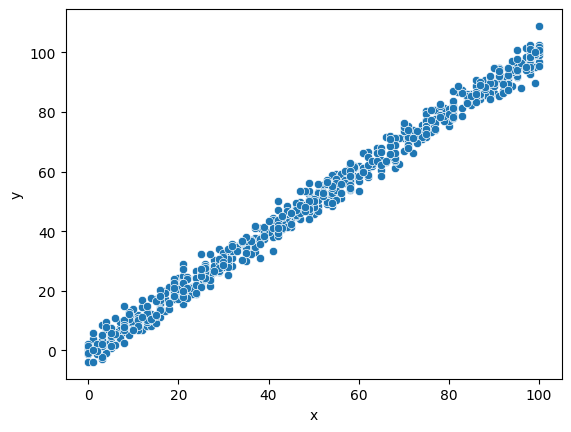

In [118]:
sb.scatterplot(x="x", y="y", data=data)

In [119]:
X_tensor = torch.tensor(data['x'].values, dtype=torch.float32).unsqueeze(dim=1)
y_Tensor = torch.tensor(data["y"].values, dtype=torch.float32).unsqueeze(dim=1)

data_train = int(len(X_tensor)*0.8)

X_train = X_tensor[:data_train]
y_train = y_Tensor[:data_train]

X_test = X_tensor[data_train:]
y_test = y_Tensor[data_train:]

In [120]:
def Graficar_data (train_x = X_train,
                   train_y = y_train,
                   test_x = X_test,
                   test_y = y_test,
                   predicciones = None):
    plt.figure(figsize=(7,7))
    plt.scatter(train_x, train_y ,s=4, c="b", label= "Train data")
    plt.scatter(test_x, test_y, s=4, c="g", label = "test data")
    
    if predicciones is not None:
        plt.scatter(test_x, predicciones, s=4,c="r", label="Prediciones" )

    plt.legend(prop= {"size":14})
    plt.show()


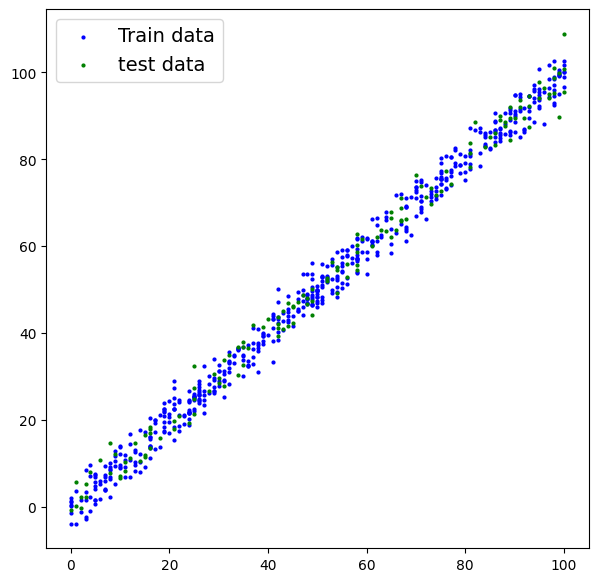

In [121]:
Graficar_data()

In [122]:
class LinearRegressionModel(nn.Module):
    # constructor 
    def __init__(self):
        super().__init__()

        self.bias = nn.Parameter(torch.rand(1,dtype=torch.float,requires_grad=True))
        self.weight = nn.Parameter(torch.rand(1,dtype=torch.float,requires_grad=True))

    def forward(self, x:torch.tensor)->torch.tensor:
       return self.weight * x + self.bias



In [123]:
torch.manual_seed(6)
modelo1 = LinearRegressionModel()

list(modelo1.parameters())
print(modelo1.state_dict())

Loss_fun = nn.L1Loss()
optimizer = torch.optim.Adam(params=modelo1.parameters(),lr=0.01)

OrderedDict([('bias', tensor([0.5722])), ('weight', tensor([0.5539]))])


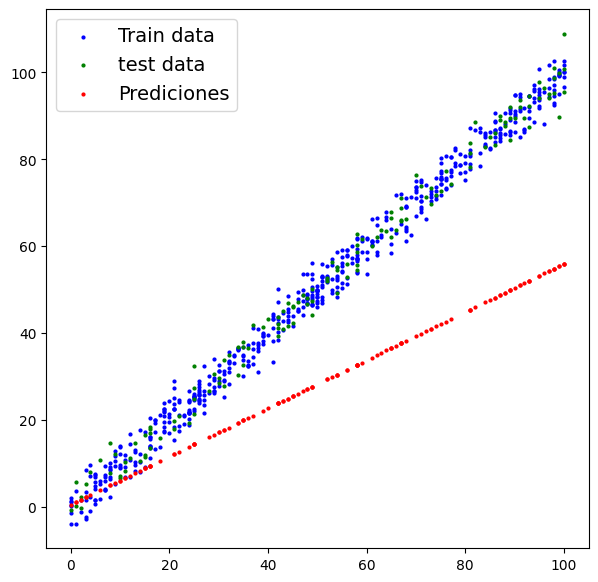

In [124]:
with torch.inference_mode():
    y_pred = modelo1(X_test) 
    
    y_pred_numpy = y_pred.detach().cpu().numpy()
Graficar_data(predicciones=y_pred_numpy)




In [125]:

epocas = 1000
contador_epocas = []
contador_loss = []
contador_test_loss = []

for epoca in range(epocas):
    ### --- ENTRENAMIENTO ---
    modelo1.train()
    y_pred1 = modelo1(X_train)
    loss = Loss_fun(y_pred1, y_train)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    ### --- EVALUACIÓN (TESTING) ---
    modelo1.eval()
    with torch.inference_mode():
        # ¡Corregido! Pasamos X_test para obtener las predicciones de prueba
        test_pred = modelo1(X_test) 
    
    # Comparamos las predicciones generadas contra las etiquetas reales
    loss_y = Loss_fun(test_pred, y_test)

    # Imprimir progreso cada 10 épocas
    if epoca % 10 == 0:
        print(f"Época: {epoca} | Pérdida Train: {loss:.4f} | Pérdida Test: {loss_y:.4f}")
        contador_epocas.append(epoca)
        contador_loss.append(loss.detach().cpu().numpy())
        contador_test_loss.append(loss_y.detach().cpu().numpy())


Época: 0 | Pérdida Train: nan | Pérdida Test: 22.2437
Época: 10 | Pérdida Train: nan | Pérdida Test: 16.9714
Época: 20 | Pérdida Train: nan | Pérdida Test: 11.7641
Época: 30 | Pérdida Train: nan | Pérdida Test: 6.7234
Época: 40 | Pérdida Train: nan | Pérdida Test: 2.6745
Época: 50 | Pérdida Train: nan | Pérdida Test: 2.6554
Época: 60 | Pérdida Train: nan | Pérdida Test: 2.3545
Época: 70 | Pérdida Train: nan | Pérdida Test: 2.3935
Época: 80 | Pérdida Train: nan | Pérdida Test: 2.3297
Época: 90 | Pérdida Train: nan | Pérdida Test: 2.2904
Época: 100 | Pérdida Train: nan | Pérdida Test: 2.2974
Época: 110 | Pérdida Train: nan | Pérdida Test: 2.3106
Época: 120 | Pérdida Train: nan | Pérdida Test: 2.3018
Época: 130 | Pérdida Train: nan | Pérdida Test: 2.2950
Época: 140 | Pérdida Train: nan | Pérdida Test: 2.2964
Época: 150 | Pérdida Train: nan | Pérdida Test: 2.2968
Época: 160 | Pérdida Train: nan | Pérdida Test: 2.2950
Época: 170 | Pérdida Train: nan | Pérdida Test: 2.2917
Época: 180 | Pérdi

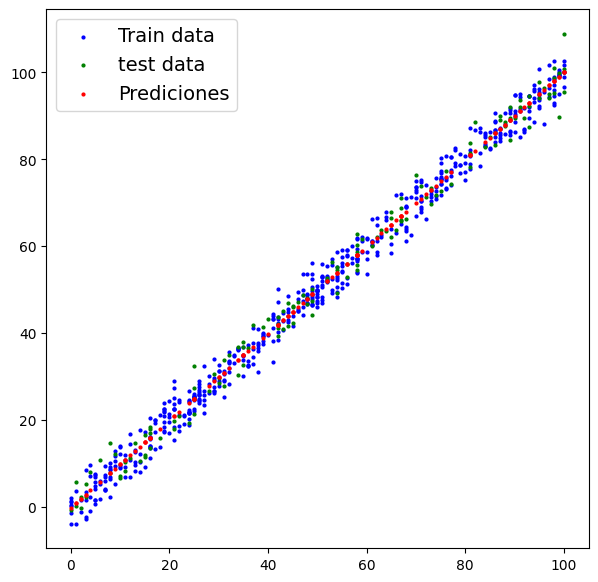

In [126]:
with torch.inference_mode():
    y_pred2 = modelo1(X_test)
    y_pred2_numpy = y_pred2.detach().cpu().numpy()

Graficar_data(predicciones=y_pred2_numpy)

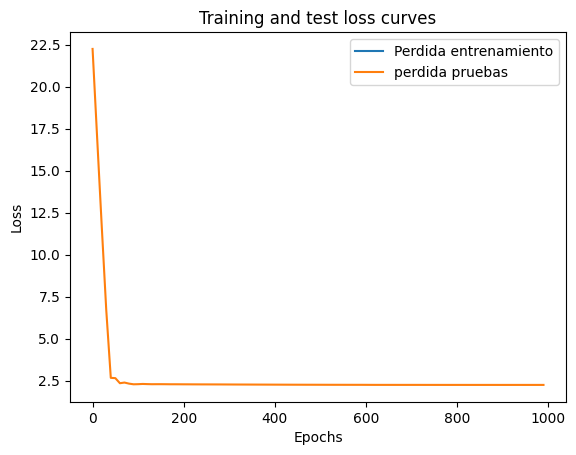

In [127]:
plt.plot(contador_epocas, contador_loss, label = "Perdida entrenamiento")
plt.plot(contador_epocas,contador_test_loss,label="perdida pruebas")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();

In [131]:
with torch.inference_mode():
    valores = modelo1(X_test)


In [134]:
modelo1.state_dict()

OrderedDict([('bias', tensor([-0.1469])), ('weight', tensor([1.0016]))])

In [136]:
modelo1.eval()
with torch.inference_mode():
    # Obtener las predicciones del set de prueba
    test_pred = modelo1(X_test)
    
    # Calcular el error promedio directo (MAE)
    mae_error = Loss_fun(test_pred, y_test)
    print(f"Error promedio (MAE) en PyTorch: {mae_error.item():.4f}")
    
    # Calcular el MSE (opcional, para ver penalización de errores grandes)
    mse_fn = torch.nn.MSELoss()
    mse_error = mse_fn(test_pred, y_test)
    print(f"Error Cuadrático (MSE) en PyTorch: {mse_error.item():.4f}")


Error promedio (MAE) en PyTorch: 2.2533
Error Cuadrático (MSE) en PyTorch: 8.0590
